<a href="https://colab.research.google.com/github/NestorRubin/Telecom_X-_an-lisis_de_evasi-n_de_clientes/blob/main/Telecom_X__an%C3%A1lisis_de_evasi%C3%B3n_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**📊 Telecom X – Análisis de Evasión de Clientes**

# 1. IMPORTAR LIBRERIAS



In [73]:
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

# 2. CARGAR DATOS DESDE LA API

In [74]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

print("Dataset cargado correctamente")
print("Filas y columnas:", df.shape)


Dataset cargado correctamente
Filas y columnas: (7267, 21)


# 3. LIMPIAR NOMBRES DE COLUMNAS

In [75]:
df.columns = df.columns.str.replace(".", "_")

print("\nColumnas del dataset:")
print(df.columns)


Columnas del dataset:
Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')


# 4. LIMPIAR DATOS IMPORTANTES

## convertir cargos totales a numero

In [76]:
df["account_Charges_Total"] = pd.to_numeric(df["account_Charges_Total"], errors="coerce")

## convertir churn a 0 y 1

In [77]:
df["Churn"] = df["Churn"].astype(str).str.strip()

df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0
})

# 5. CREAR COLUMNA DE CARGOS DIARIOS

In [78]:
df["DailyCharges"] = df["account_Charges_Monthly"] / 30

# 6. EXPLORAR DATASET

In [79]:
print("\nValores de Churn:")
print(df["Churn"].value_counts())

print("\nDescripción estadística:")
print(df.describe())


Valores de Churn:
Churn
0    5174
1    1869
      224
Name: count, dtype: int64

Descripción estadística:
       customer_SeniorCitizen  customer_tenure  account_Charges_Monthly  \
count             7267.000000      7267.000000              7267.000000   
mean                 0.162653        32.346498                64.720098   
std                  0.369074        24.571773                30.129572   
min                  0.000000         0.000000                18.250000   
25%                  0.000000         9.000000                35.425000   
50%                  0.000000        29.000000                70.300000   
75%                  0.000000        55.000000                89.875000   
max                  1.000000        72.000000               118.750000   

       account_Charges_Total  DailyCharges  
count            7256.000000   7267.000000  
mean             2280.634213      2.157337  
std              2268.632997      1.004319  
min                18.800000      0.6

# 7. GRAFICO DE DISTRIBUCION CHURN

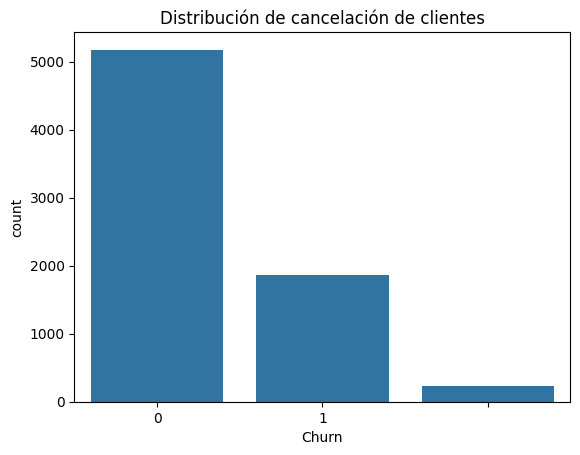

In [80]:
sns.countplot(x="Churn", data=df)

plt.title("Distribución de cancelación de clientes")

plt.show()

# 8. CHURN POR TIPO DE CONTRATO

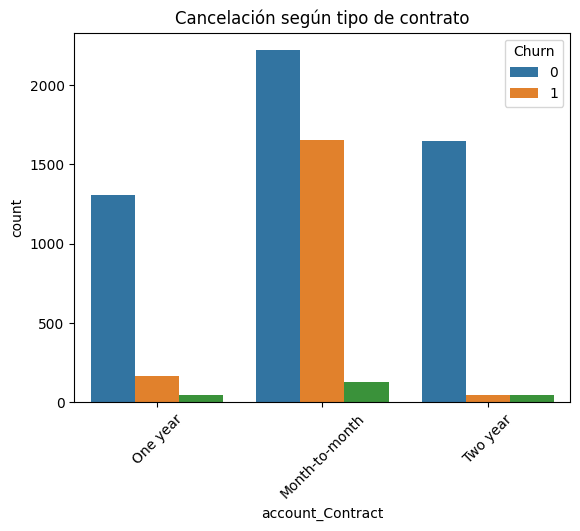

In [81]:
sns.countplot(x="account_Contract", hue="Churn", data=df)

plt.xticks(rotation=45)

plt.title("Cancelación según tipo de contrato")

plt.show()

# 9. TENURE VS CHURN

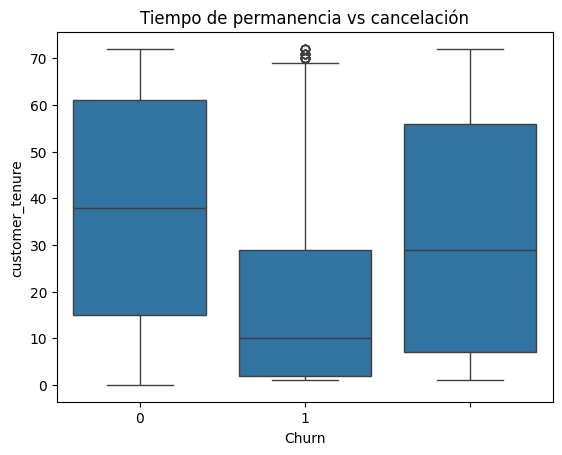

In [82]:
sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Tiempo de permanencia vs cancelación")

plt.show()

# 10. CARGOS MENSUALES VS CHURN

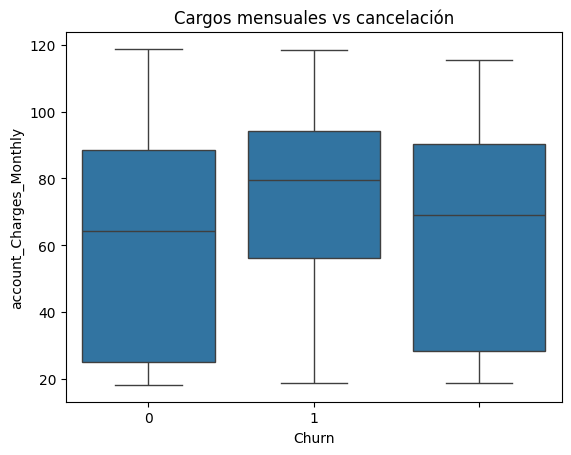

In [83]:
sns.boxplot(x="Churn", y="account_Charges_Monthly", data=df)

plt.title("Cargos mensuales vs cancelación")

plt.show()

#📊 1. Gráfico de churn por tipo de internet

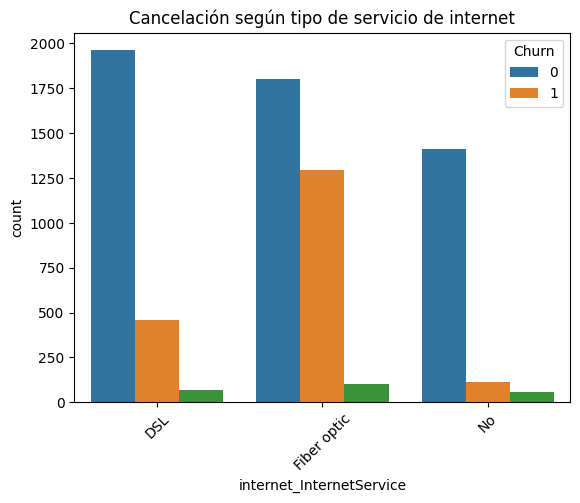

In [84]:
sns.countplot(x="internet_InternetService", hue="Churn", data=df)

plt.title("Cancelación según tipo de servicio de internet")

plt.xticks(rotation=45)

plt.show()

##Observación

Los clientes con servicio de fibra óptica presentan mayor tasa de cancelación que otros tipos de servicio.

#📊 2. Churn por método de pago

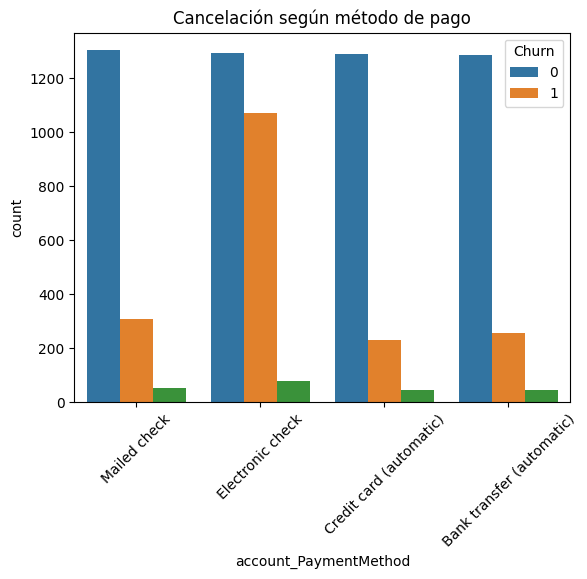

In [87]:
sns.countplot(x="account_PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)

plt.title("Cancelación según método de pago")

plt.show()

##Observación

Algunos métodos de pago presentan mayor tasa de cancelación, lo que podría indicar menor compromiso del cliente.

#📊 3. Correlación entre variables (extra)

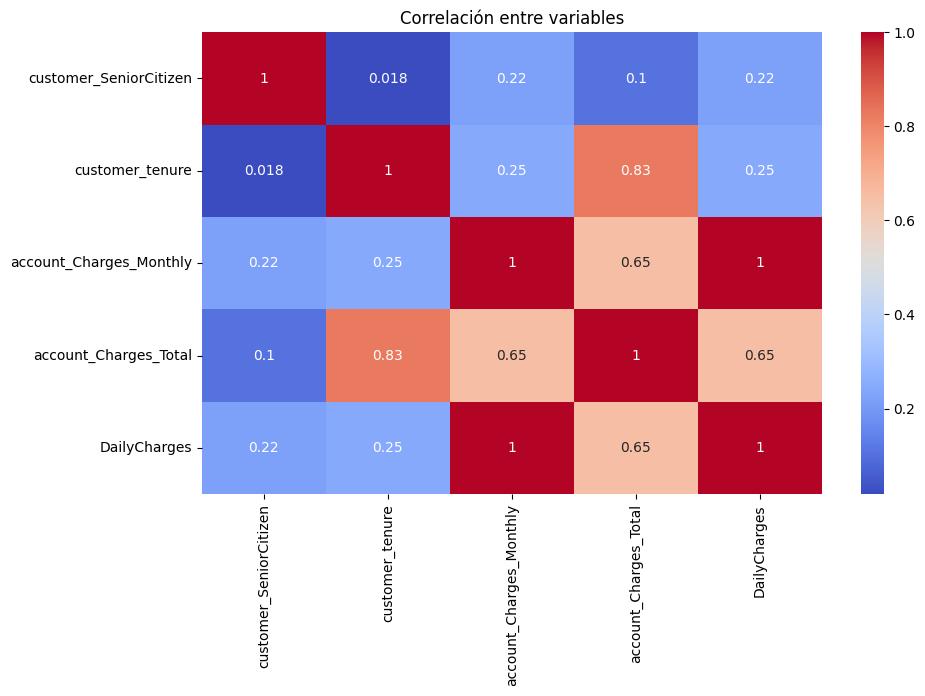

In [86]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlación entre variables")

plt.show()

#**📑 Conclusiones del análisis**


#Hallazgos principales

1. Los clientes con contratos mensuales presentan mayor tasa de cancelación.

2. Los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar el servicio.

3. Los clientes con cargos mensuales más altos tienden a cancelar con mayor frecuencia.

4. Algunos métodos de pago y tipos de servicio de internet presentan mayor tasa de evasión.


#Recomendaciones para Telecom X


* Incentivar contratos de largo plazo.

* Crear programas de fidelización para clientes nuevos.

* Analizar estrategias de precios para clientes con cargos altos.

* Implementar modelos predictivos de churn para identificar clientes en riesgo.